# 04 - Surface Generation Rules

## Aim
This notebook translates image clustering results into grayscale height maps for 3D surface generation.

The goal is to transform extracted visual patterns into a set of architectural surface logics that can later be applied in Blender through displacement.

## Strategy
Three simplified surface modes are tested:

- Base: smooth continuous surface
- Hard Edge: stepped architectural block surface
- Binary: highly reduced massing surface

These variations are used to evaluate which surface language best reflects brutalist architectural characteristics.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

In [2]:
output_dir = Path("../outputs/heightmaps")
output_dir.mkdir(parents=True, exist_ok=True)

print(output_dir.resolve())

D:\Work\Workspace\Projects\Python\data-driven-surface\outputs\heightmaps


In [3]:
def normalize_array(Z):
    Z = Z - Z.min()
    if Z.max() > 0:
        Z = Z / Z.max()
    return Z


def save_heightmap(Z, save_path):
    Z_norm = normalize_array(Z)
    img = (Z_norm * 255).astype(np.uint8)
    Image.fromarray(img).save(save_path)

In [4]:
def generate_base_surface(surface_type="grid", size=256):
    x = np.linspace(-1, 1, size)
    y = np.linspace(-1, 1, size)
    X, Y = np.meshgrid(x, y)

    if surface_type == "grid":
        Z = np.sin(X * 10) * np.sin(Y * 10)

    elif surface_type == "layered":
        Z = np.sin(Y * 12) * 0.7 + np.sin(X * 4) * 0.3

    elif surface_type == "smooth_mass":
        Z = np.exp(-(X**2 + Y**2) * 3)

    elif surface_type == "skeletal":
        Z = np.abs(np.sin(X * 8)) * 0.6 + np.abs(np.sin(Y * 4)) * 0.4

    else:
        Z = np.zeros((size, size))

    return normalize_array(Z)

In [5]:
def variation_base(Z):
    return normalize_array(Z)


def variation_hard_edge(Z):
    Z = normalize_array(Z)
    Z_hard = np.round(Z * 3) / 3
    return normalize_array(Z_hard)


def variation_binary(Z):
    Z = normalize_array(Z)
    Z_binary = (Z > 0.5).astype(float)
    return normalize_array(Z_binary)

In [6]:
Z_base_source = generate_base_surface(surface_type="grid", size=256)

Z_base = variation_base(Z_base_source)
Z_hard = variation_hard_edge(Z_base_source)
Z_binary = variation_binary(Z_base_source)

print(Z_base.shape, Z_hard.shape, Z_binary.shape)

(256, 256) (256, 256) (256, 256)


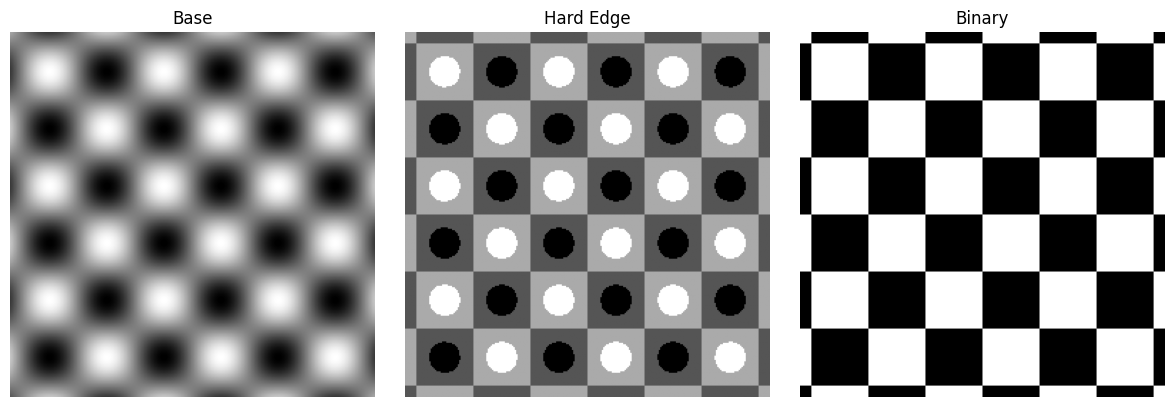

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(Z_base, cmap="gray")
axes[0].set_title("Base")
axes[0].axis("off")

axes[1].imshow(Z_hard, cmap="gray")
axes[1].set_title("Hard Edge")
axes[1].axis("off")

axes[2].imshow(Z_binary, cmap="gray")
axes[2].set_title("Binary")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [8]:
save_heightmap(Z_base, output_dir / "heightmap_base.png")
save_heightmap(Z_hard, output_dir / "heightmap_hard_edge.png")
save_heightmap(Z_binary, output_dir / "heightmap_binary.png")

print("Saved:")
print(output_dir / "heightmap_base.png")
print(output_dir / "heightmap_hard_edge.png")
print(output_dir / "heightmap_binary.png")

Saved:
..\outputs\heightmaps\heightmap_base.png
..\outputs\heightmaps\heightmap_hard_edge.png
..\outputs\heightmaps\heightmap_binary.png


In [9]:
# choose one:
# final_Z = Z_base
final_Z = Z_hard
# final_Z = Z_binary

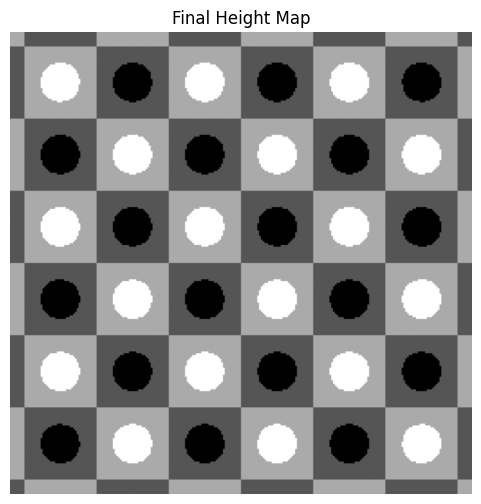

In [10]:
plt.figure(figsize=(6, 6))
plt.imshow(final_Z, cmap="gray")
plt.title("Final Height Map")
plt.axis("off")
plt.show()

In [11]:
final_path = output_dir / "final_heightmap.png"
save_heightmap(final_Z, final_path)

print("Final height map saved to:")
print(final_path.resolve())

Final height map saved to:
D:\Work\Workspace\Projects\Python\data-driven-surface\outputs\heightmaps\final_heightmap.png


## Interpretation

Three surface modes were tested from the same base structure.

- **Base** preserves continuous gradients and reads more like terrain or soft deformation.
- **Hard Edge** reduces the surface into stepped levels, creating a stronger architectural block language.
- **Binary** further simplifies the logic into mass / void relationships, producing a more abstract brutalist massing model.

For Blender displacement, the **Hard Edge** version was selected because it retains modular repetition while avoiding excessive smoothness or purely graphic abstraction.

In [12]:
def save_scaled_heightmap(Z, scale_name, gamma, save_dir):
    Z_scaled = normalize_array(Z) ** gamma
    save_heightmap(Z_scaled, save_dir / f"final_heightmap_{scale_name}.png")


save_scaled_heightmap(final_Z, "soft", gamma=1.5, save_dir=output_dir)
save_scaled_heightmap(final_Z, "normal", gamma=1.0, save_dir=output_dir)
save_scaled_heightmap(final_Z, "strong", gamma=0.7, save_dir=output_dir)

print("Saved scaled variants: soft / normal / strong")

Saved scaled variants: soft / normal / strong
